## Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    precision_recall_curve,
    f1_score
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import clone

## Load MNIST Dataset

In [3]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

shuffle_index = np.random.permutation(60000)
X_train, y_train = X_train[shuffle_index], y_train[shuffle_index]

## Part 1: Cross-validation using StratifiedKFold

Cross-validation
1. Using StratifiedKFold, implement your own CROSS-VALIDATION.


Build the binary targets first.

In [4]:
y_train_2 = (y_train == '2')
y_test_2 = (y_test == '2')

In [7]:
y_train_2

array([False, False, False, ..., False, False, False])

In [8]:
y_test_2

array([False,  True, False, ..., False, False, False])

Manual Cross-validation Code

In [9]:
sgd_clf = SGDClassifier(random_state=42)

skfolds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_scores = []

for train_index, val_index in skfolds.split(X_train, y_train_2):
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_2[train_index]
    X_val_fold = X_train[val_index]
    y_val_fold = y_train_2[val_index]

    clone_clf = clone(sgd_clf)
    clone_clf.fit(X_train_folds, y_train_folds)

    y_pred = clone_clf.predict(X_val_fold)
    n_correct = np.sum(y_pred == y_val_fold)
    accuracy = n_correct / len(y_val_fold)
    cv_scores.append(accuracy)

print("Cross-validation accuracies:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))

Cross-validation accuracies: [np.float64(0.96565), np.float64(0.9621), np.float64(0.97605)]
Mean CV accuracy: 0.9679333333333333


## Part 2: Plotting Recall and Precision Curves

2.1 Recall, Precision and Threshold Array Shapes

1. Why is the slicing “[:-1]" needed for the arguments “precisions[:-1]"
and “recalls[:-1]" in the following code fragment:


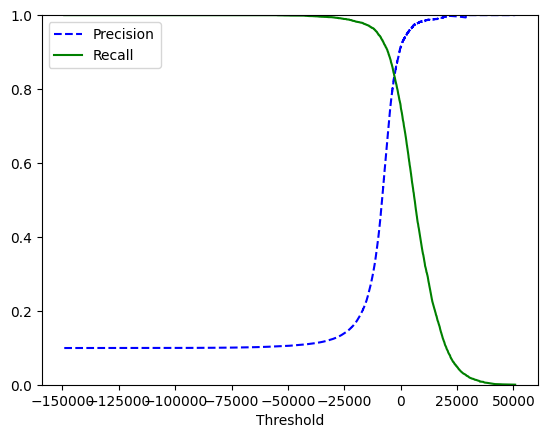

In [12]:
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_predict

y_scores = cross_val_predict(sgd_clf, X_train, y_train_2, cv=3, method="decision_function")

precisions, recalls, thresholds = precision_recall_curve(y_train_2, y_scores)

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
  plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
  plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
  plt.xlabel("Threshold")
  plt.legend(loc="upper left")
  plt.ylim([0, 1])

plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

In [13]:
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)

print("Best index:", best_idx)
print("Best threshold:", thresholds[best_idx])
print("Precision at best threshold:", precisions[best_idx])
print("Recall at best threshold:", recalls[best_idx])
print("Best F1:", f1_scores[best_idx])

Best index: 54210
Best threshold: -2401.83005805557
Precision at best threshold: 0.8499136442141624
Recall at best threshold: 0.8259483048002686
Best F1: 0.8377596186085053


In [15]:
# 2.2(c) Based on these thresholds, calculate the new precision score
best_threshold = thresholds[best_idx]
y_train_pred_high_precision = (y_scores >= best_threshold)
new_precision = precision_score(y_train_2, y_train_pred_high_precision)
print("New precision:", new_precision)

new_recall = recall_score(y_train_2, y_train_pred_high_precision)
print("New Recall:", new_recall)

New precision: 0.8499136442141624
New Recall: 0.8259483048002686


## Multioutput Classification
In the “Multioutput Classification" of last week’s lecture, we introduced noise into MNIST training data and where we cleaned it afterwards using multioutput classification. Try and plot some of the digits as follows:
Plot ten of the digits (should include all the digits: 0, 1, 2,..., 9) from the original MNIST training data and also the corresponding instance with the noise introduced (e.g., see Slide No. 10 of this Week 3 lec- ture);
Plot the corresponding digit instances after cleaning.


In [16]:
def plot_digit(data):
  image = data.reshape(28, 28)
  plt.imshow(image, cmap=matplotlib.cm.binary, interpolation="nearest")
  plt.axis("off")

def plot_digits(instances, images_per_row=10):
  plt.figure(figsize=(12, 3))
  for i, instance in enumerate(instances):
    plt.subplot(1, len(instances), i + 1)
    plot_digit(instance)
  plt.show()

In [17]:
# Find one example of each
y_train_int = y_train.astype(np.int64)

sample_indices = []
for digit in range(10):
  idx = np.where(y_train_int == digit)[0][0]
  sample_indices.append(idx)

original_digits = X_train[sample_indices]

In [18]:
# Add noise to all training and test images
noise_train = np.random.randint(0, 100, (len(X_train), 784))
noise_test = np.random.randint(0, 100, (len(X_test), 784))

X_train_mod = X_train + noise_train
X_test_mod = X_test + noise_test

y_train_mod = X_train
y_test_mod = X_test

Original digits:


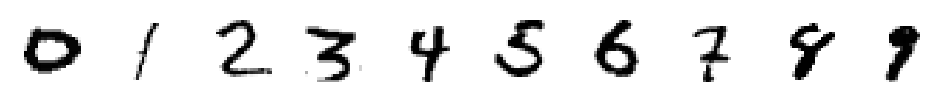

Noisy digits:


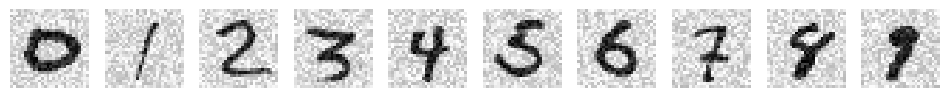

In [19]:
# Plot original and noisy versions for digits 0–9
noisy_digits = X_train_mod[sample_indices]

print("Original digits:")
plot_digits(original_digits)

print("Noisy digits:")
plot_digits(noisy_digits)

In [20]:
# Train KNN to clean images
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)

KNeighborsClassifier()

Cleaned digits:


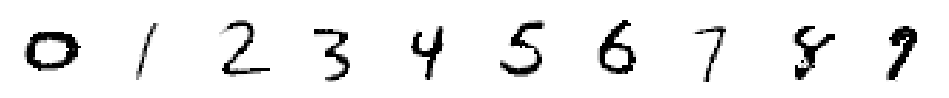

In [21]:
# Predict cleaned versions and plot them
cleaned_digits = knn_clf.predict(noisy_digits)

print("Cleaned digits:")
plot_digits(cleaned_digits)